In [ ]:
import gzip
import pickle 
import matplotlib
matplotlib.rc('font', size=15)
import torch 
import pandas as pd
import numpy as np
import plotly.express as px
import sys
sys.path.append("/afs/cern.ch/work/m/mgarciam/private/mlpf/")
from scipy.optimize import linear_sum_assignment
import matplotlib.pyplot as plt

: 

In [ ]:
import matplotlib
import sys
import os
from src.utils.inference.per_particle_metrics import plot_per_energy_resolution, reco_hist, \
    plot_mass_contribution_per_category, plot_mass_contribution_per_PID
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
import mplhep as hep
from src.utils.inference.pandas_helpers import open_mlpf_dataframe, concat_with_batch_fix
from src.utils.inference.per_particle_metrics import (
    plot_per_energy_resolution2_multiple, plot_confusion_matrix, plot_confusion_matrix_pandora
    , calc_unit_circle_dist, plot_per_energy_resolution2, analyze_fakes, analyze_fakes_PID,
    plot_cm_per_energy, plot_fake_and_missed_energy_regions, quick_plot_mass,
    plot_cm_per_energy_on_overview
)
from src.utils.inference.efficiency_calc_and_plots import plot_efficiency_all
from src.utils.inference.track_cluster_eff_plots import plot_track_assignation_eval
from src.utils.inference.event_Ks import get_decay_type
import matplotlib.pyplot as plt
import torch
import pickle
from src.evaluation.refactor.preprocess import preprocess_dataframe, renumber_batch_idx
hep.style.use("CMS")
font = {'size': 10}
matplotlib.rc('font', **font)
import argparse


PATH_store = os.path.join("/eos/user/m/mgarciam/datasets_mlpf/models_trained_CLD/041225_arc_05/", "paper_plots")
PATH_store_summary_plots = os.path.join(PATH_store, "summary_plots")





dir_top = "/eos/user/m/mgarciam/datasets_mlpf/models_trained_CLD/041225_arc_05/"

sd_hgb1, _ = open_mlpf_dataframe(os.path.join(dir_top, "showers_df_evaluation/05_EPID_all0_0_None.pt"), False, False)
sd_hgb = sd_hgb1 #concat_with_batch_fix([sd_hgb1, sd_hgb2, sd_hgb3])

sd_pandora1, _ = open_mlpf_dataframe(os.path.join(dir_top, "showers_df_evaluation/05_EPID_all0_0_None_pandora.pt"), False, False)
sd_pandora = sd_pandora1 #concat_with_batch_fix([sd_pandora1, sd_pandora2, sd_pandora3])

sd_hgb_gt1, _ = open_mlpf_dataframe(os.path.join(dir_top, "showers_df_evaluation/test_gun_um1000_0_None.pt"), False, False)
sd_hgb_gt = sd_hgb_gt1 #concat_with_batch_fix([sd_hgb_gt1, sd_hgb_gt2, sd_hgb_gt3])

sd_hgb, sd_pandora = preprocess_dataframe(sd_hgb, sd_pandora, "")

mask = (sd_hgb.pred_pid_matched==4)*(sd_hgb.calibrated_E<1.5)
sd_hgb.loc[mask, "pred_pid_matched"]=1



: 

In [3]:
# Initialise dictionaries
calc_fakes = sd_pandora is not None
pandora = calc_fakes
from src.utils.inference.efficiency_calc_and_plots import create_eff_dic_pandora,create_eff_dic, limit_error_bars


fs = 15
font = {'size': fs}
matplotlib.rc('font', **font)
hep.style.use("CMS")
from src.evaluation.plots_paper_HitPF.plot_clustering import particles,plot_error_bars, plot_error_bars_pandora, pot_error_bar_fakes, pot_error_bar_fakes_pandora
size_font=15
eff_dic = {
    k: create_eff_dic_pandora(sd_pandora, v["pid"]) if pandora else {}
    for k, v in particles.items()
}


/afs/cern.ch/work/m/mgarciam/private/mlpf/src/utils/inference/efficiency_calc_and_plots.py:463: UserWarning: evaluating in Python space because the '*' operator is not supported by numexpr for the bool dtype, use '&' instead.
  mask_pid_truth = mask_above * mask_below * sd.pid.isin(our_to_pandora_mapping[id_our]) # The matched ones
/afs/cern.ch/work/m/mgarciam/private/mlpf/src/utils/inference/efficiency_calc_and_plots.py:464: UserWarning: evaluating in Python space because the '*' operator is not supported by numexpr for the bool dtype, use '&' instead.
  mask = mask_below * mask_above * mask_pid


In [4]:

# Fill dictionaries from HGB dataframes
df_list = [sd_hgb]
for var_i, sd_hgb in enumerate(df_list):
    for k, v in particles.items():
        eff_dic[k] = create_eff_dic(
            eff_dic[k], sd_hgb, v["pid"],
            var_i=var_i,
            calc_fakes=calc_fakes
        )


/afs/cern.ch/work/m/mgarciam/private/mlpf/src/utils/inference/efficiency_calc_and_plots.py:478: UserWarning: evaluating in Python space because the '*' operator is not supported by numexpr for the bool dtype, use '&' instead.
  mask = mask_below * mask_above * mask_pid


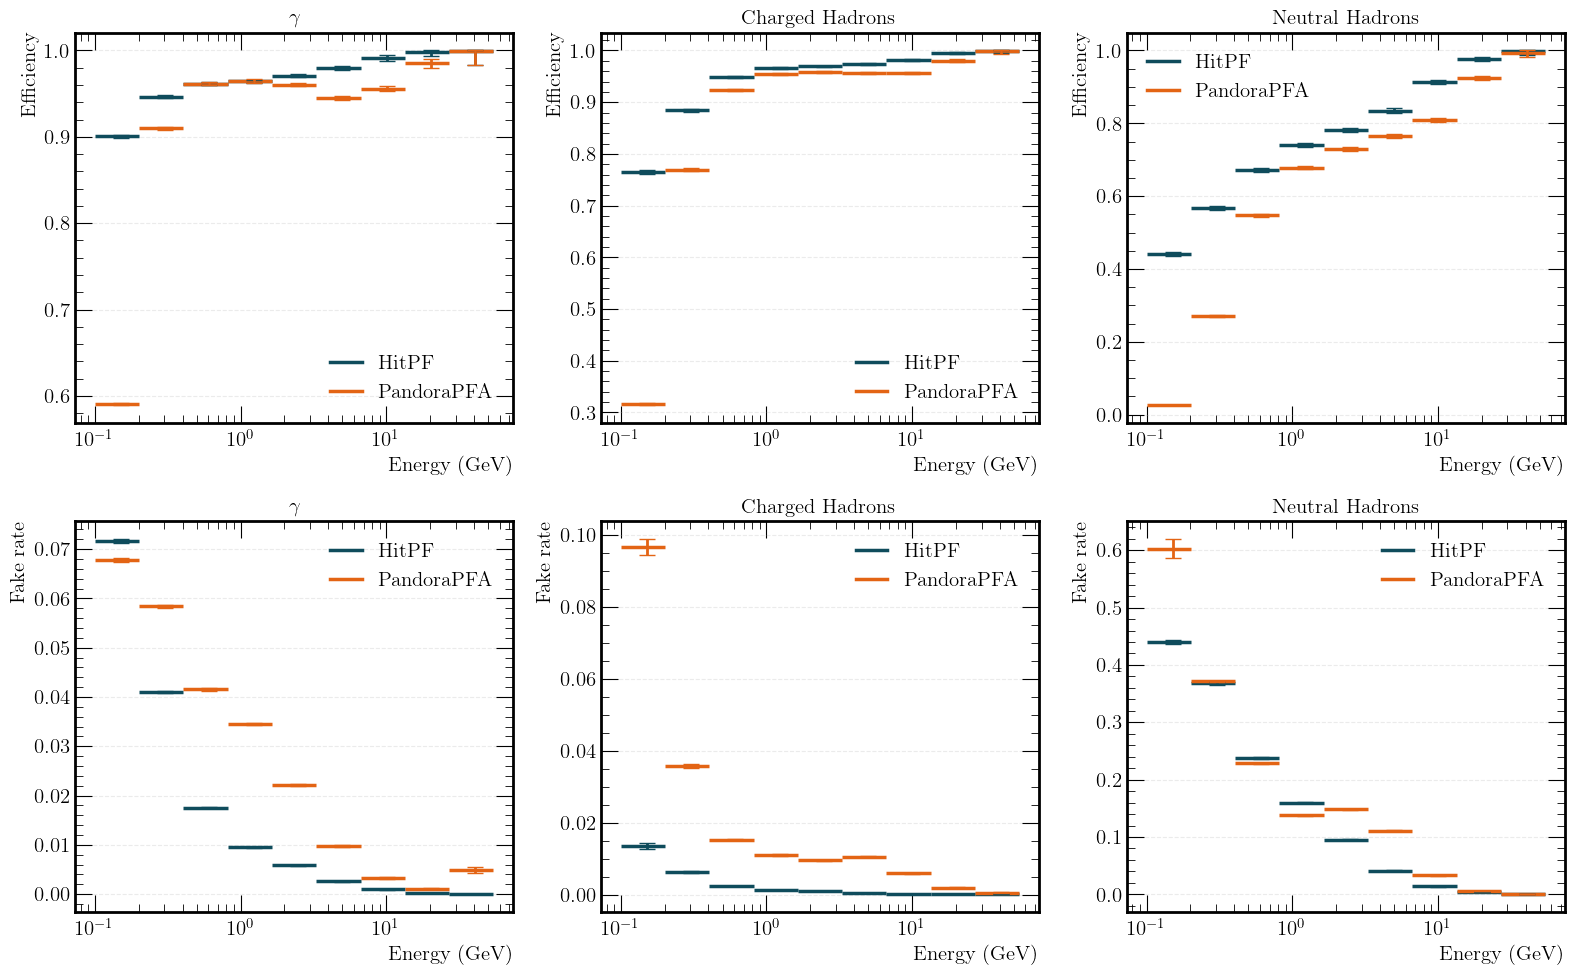

In [7]:
# LINES VERSION
# ################################## Efficiency & Fake-rate plot #####################################################################################################
####################################################################################################################################################################
fig_eff, ax_eff = plt.subplots(2, 3, figsize=(16, 10))

import matplotlib
from matplotlib.lines import Line2D
import numpy as np
import os

plt.rc("text", usetex=True)
plt.rc("font", family="serif")

STYLE_OURS = dict(color="#0F4C5C")
STYLE_PANDORA = dict(color="#E36414")

# -------------------------------------------------
# Bin definition (shared everywhere)
# -------------------------------------------------
bins = np.exp(np.arange(np.log(0.1), np.log(80), 0.3))

# =================================================
# =============== EFFICIENCIES ====================
# =================================================

# ---------- Photons ----------
ax = ax_eff[0,0]
ax.set_title(r"$\gamma$", fontsize=size_font)
ax.set_xlabel("Energy (GeV)", fontsize=size_font)
ax.set_ylabel("Efficiency", fontsize=size_font)

ax.hlines(
    eff_dic["photons"]["eff_0"],
    xmin=bins[:-1],
    xmax=bins[1:],
    linewidth=2.5,
    **STYLE_OURS
)

ax.hlines(
    eff_dic["photons"]["eff_p"],
    xmin=bins[:-1],
    xmax=bins[1:],
    linewidth=2.5,
    **STYLE_PANDORA
)

plot_error_bars(eff_dic["photons"], ax, "")
plot_error_bars_pandora(eff_dic["photons"], ax, "")

# ---------- Charged hadrons ----------
ax = ax_eff[0,1]
ax.set_title("Charged Hadrons", fontsize=size_font)
ax.set_xlabel("Energy (GeV)", fontsize=size_font)
ax.set_ylabel("Efficiency", fontsize=size_font)

ax.hlines(
    eff_dic["pions"]["eff_0"],
    xmin=bins[:-1],
    xmax=bins[1:],
    linewidth=2.5,
    **STYLE_OURS
)

ax.hlines(
    eff_dic["pions"]["eff_p"],
    xmin=bins[:-1],
    xmax=bins[1:],
    linewidth=2.5,
    **STYLE_PANDORA
)

plot_error_bars(eff_dic["pions"], ax, "")
plot_error_bars_pandora(eff_dic["pions"], ax, "")

# ---------- Neutral hadrons ----------
ax = ax_eff[0,2]
ax.set_title("Neutral Hadrons", fontsize=size_font)
ax.set_xlabel("Energy (GeV)", fontsize=size_font)
ax.set_ylabel("Efficiency", fontsize=size_font)

ax.hlines(
    eff_dic["kaons"]["eff_0"],
    xmin=bins[:-1],
    xmax=bins[1:],
    linewidth=2.5,
    **STYLE_OURS
)

ax.hlines(
    eff_dic["kaons"]["eff_p"],
    xmin=bins[:-1],
    xmax=bins[1:],
    linewidth=2.5,
    **STYLE_PANDORA
)

plot_error_bars(eff_dic["kaons"], ax, "")
plot_error_bars_pandora(eff_dic["kaons"], ax, "")

# =================================================
# ================= FAKE RATES ====================
# =================================================

# ---------- Photons ----------
ax = ax_eff[1,0]
ax.set_title(r"$\gamma$", fontsize=size_font)
ax.set_xlabel("Energy (GeV)", fontsize=size_font)
ax.set_ylabel("Fake rate", fontsize=size_font)

ax.hlines(
    eff_dic["photons"]["fakes_0"],
    xmin=bins[:-1],
    xmax=bins[1:],
    linewidth=2.5,
    **STYLE_OURS
)

ax.hlines(
    eff_dic["photons"]["fakes_p"],
    xmin=bins[:-1],
    xmax=bins[1:],
    linewidth=2.5,
    **STYLE_PANDORA
)

pot_error_bar_fakes(eff_dic["photons"], ax, i=0)
pot_error_bar_fakes_pandora(eff_dic["photons"], ax, i=0)

# ---------- Charged hadrons ----------
ax = ax_eff[1,1]
ax.set_title("Charged Hadrons", fontsize=size_font)
ax.set_xlabel("Energy (GeV)", fontsize=size_font)
ax.set_ylabel("Fake rate", fontsize=size_font)

ax.hlines(
    eff_dic["pions"]["fakes_0"],
    xmin=bins[:-1],
    xmax=bins[1:],
    linewidth=2.5,
    **STYLE_OURS
)

ax.hlines(
    eff_dic["pions"]["fakes_p"],
    xmin=bins[:-1],
    xmax=bins[1:],
    linewidth=2.5,
    **STYLE_PANDORA
)

pot_error_bar_fakes(eff_dic["pions"], ax, i=0)
pot_error_bar_fakes_pandora(eff_dic["pions"], ax, i=0)

# ---------- Neutral hadrons ----------
ax = ax_eff[1,2]
ax.set_title("Neutral Hadrons", fontsize=size_font)
ax.set_xlabel("Energy (GeV)", fontsize=size_font)
ax.set_ylabel("Fake rate", fontsize=size_font)

ax.hlines(
    eff_dic["kaons"]["fakes_0"],
    xmin=bins[:-1],
    xmax=bins[1:],
    linewidth=2.5,
    **STYLE_OURS
)

ax.hlines(
    eff_dic["kaons"]["fakes_p"],
    xmin=bins[:-1],
    xmax=bins[1:],
    linewidth=2.5,
    **STYLE_PANDORA
)

pot_error_bar_fakes(eff_dic["kaons"], ax, i=0)
pot_error_bar_fakes_pandora(eff_dic["kaons"], ax, i=0)

# =================================================
# ================= COSMETICS =====================
# =================================================

legend_elements = [
    Line2D([0], [0], color="#0F4C5C", lw=2.5, label="HitPF"),
    Line2D([0], [0], color="#E36414", lw=2.5, label="PandoraPFA"),
]

for ax in ax_eff.flatten():
    ax.grid(True, axis="y", alpha=0.25, linestyle="--")
    ax.set_axisbelow(True)
    ax.set_xscale("log")
    ax.legend(handles=legend_elements, fontsize=size_font)
    ax.tick_params(axis="both", which="major", labelsize=size_font)
    ax.tick_params(axis="both", which="minor", labelsize=size_font)

plt.rcParams["font.size"] = size_font
plt.rcParams["font.family"] = "serif"
plt.rcParams["xtick.labelsize"] = size_font
plt.rcParams["ytick.labelsize"] = size_font

fig_eff.tight_layout()
fig_eff.savefig(
    os.path.join(PATH_store_summary_plots, "overview_Efficiency_FakeRate_v1.pdf")
)



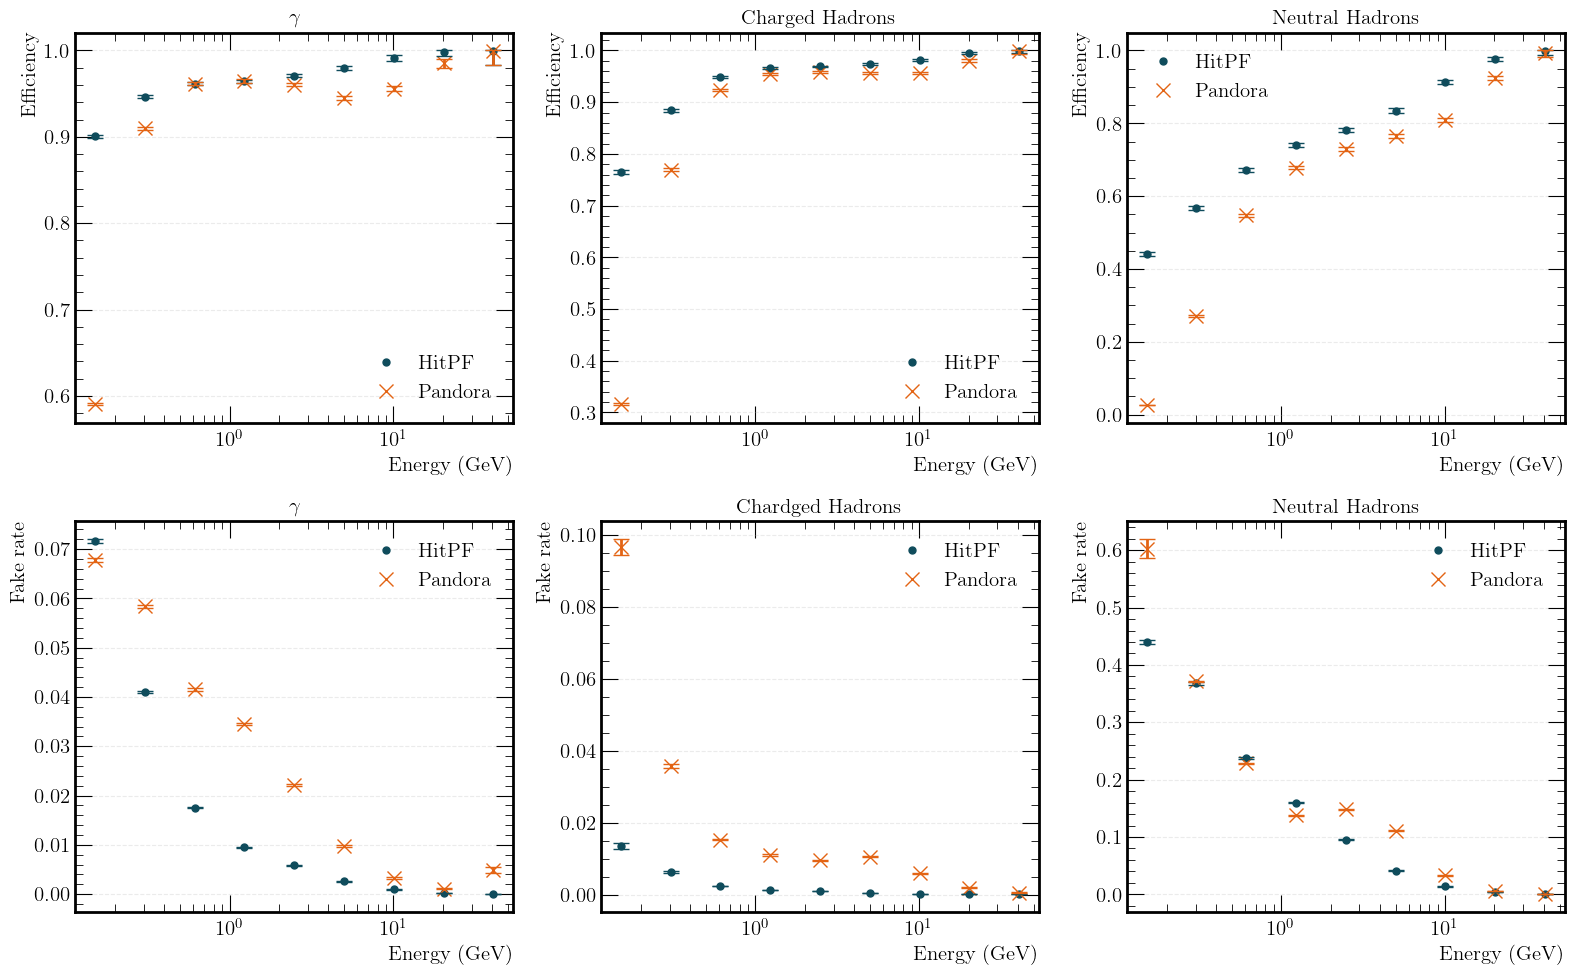

In [10]:
################################### Efficiency plot #####################################################################################################################################################################
######################################################################################################################################################################################################
fig_eff, ax_eff = plt.subplots(2, 3, figsize=(16, 10))
import matplotlib
plt.rc("text", usetex=True)
plt.rc("font", family="serif")

colors_list = ["#0F4C5C", "#E36414", "#E36414"]
STYLE_OURS = dict(color="#0F4C5C",  marker='.', linestyle='None', markersize=10) #lw=2.5, 
STYLE_PANDORA = dict(color="#E36414",  marker='x', linestyle='None', markersize=10)
ax_eff[0,0].plot(eff_dic["photons"]["energy_eff_" + str(0)],
            eff_dic["photons"]["eff" + "_" + str(0)], **STYLE_OURS, label="HitPF",)
ax_eff[0,0].plot(eff_dic["photons"]["energy_eff_p"],
            eff_dic["photons"]["eff_p"], **STYLE_PANDORA, label="Pandora",)
ax_eff[0,0].set_xlabel("Energy (GeV)",fontsize=size_font)
ax_eff[0,0].set_ylabel("Efficiency",fontsize=size_font)
ax_eff[0,0].set_title(r"$\gamma$",fontsize=size_font)
plot_error_bars(eff_dic["photons"],ax_eff[0,0], "")
plot_error_bars_pandora(eff_dic["photons"],ax_eff[0,0], "")

y = eff_dic["photons"]["eff_0"]
#################################
ax_eff[0,1].plot(eff_dic["pions"]["energy_eff_" + str(0)],
            eff_dic["pions"]["eff" + "_" + str(0)],  label="HitPF", **STYLE_OURS)
ax_eff[0,1].plot(eff_dic["pions"]["energy_eff_p"],
            eff_dic["pions"]["eff_p"], label="Pandora", **STYLE_PANDORA)
plot_error_bars(eff_dic["pions"],ax_eff[0,1], "")
ax_eff[0,1].set_title("Charged Hadrons",fontsize=size_font)
ax_eff[0,1].set_xlabel("Energy (GeV)",fontsize=size_font)
ax_eff[0,1].set_ylabel("Efficiency",fontsize=size_font)
plot_error_bars_pandora(eff_dic["pions"],ax_eff[0,1], "")
#################################
ax_eff[0,2].plot(eff_dic["kaons"]["energy_eff_" + str(0)],
            eff_dic["kaons"]["eff" + "_" + str(0)], label="HitPF", **STYLE_OURS)
ax_eff[0,2].plot(eff_dic["kaons"]["energy_eff_p"],
            eff_dic["kaons"]["eff_p"], label="Pandora", **STYLE_PANDORA)
plot_error_bars(eff_dic["kaons"],ax_eff[0,2], "")
plot_error_bars_pandora(eff_dic["kaons"],ax_eff[0,2], "")
ax_eff[0,2].set_xlabel("Energy (GeV)",fontsize=size_font)
ax_eff[0,2].set_title("Neutral Hadrons",fontsize=size_font)
ax_eff[0,2].set_ylabel("Efficiency",fontsize=size_font)

##Fake rate #################################
ax_eff[1,0].plot(eff_dic["photons"]["energy_fakes_" + str(0)],
            eff_dic["photons"]["fakes_" + str(0)],  label="HitPF", **STYLE_OURS)
ax_eff[1,0].plot(eff_dic["photons"]["energy_fakes_p"],
        eff_dic["photons"]["fakes_p"], label="Pandora", **STYLE_PANDORA)
ax_eff[1,0].set_xlabel("Energy (GeV)",fontsize=size_font)
ax_eff[1,0].set_ylabel("Fake rate",fontsize=size_font)
ax_eff[1,0].set_title(r"$\gamma$",fontsize=size_font)
pot_error_bar_fakes(eff_dic["photons"], ax_eff[1,0], i=0)
pot_error_bar_fakes_pandora(eff_dic["photons"], ax_eff[1,0], i=0)
#################################
ax_eff[1,1].plot(eff_dic["pions"]["energy_fakes_" + str(0)],
    eff_dic["pions"]["fakes_" + str(0)],  label="HitPF", **STYLE_OURS)
ax_eff[1,1].plot(eff_dic["pions"]["energy_fakes_p"],
        eff_dic["pions"]["fakes_p"], label="Pandora", **STYLE_PANDORA)
ax_eff[1,1].set_xlabel("Energy (GeV)",fontsize=size_font)
ax_eff[1,1].set_ylabel("Fake rate",fontsize=size_font)
ax_eff[1,1].set_title("Chardged Hadrons",fontsize=size_font)
pot_error_bar_fakes(eff_dic["pions"], ax_eff[1,1], i=0)
pot_error_bar_fakes_pandora(eff_dic["pions"], ax_eff[1,1], i=0)

ax_eff[1,2].plot(eff_dic["kaons"]["energy_fakes_" + str(0)],
    eff_dic["kaons"]["fakes_" + str(0)],  label="HitPF", **STYLE_OURS)
ax_eff[1,2].plot(eff_dic["kaons"]["energy_fakes_p"],
        eff_dic["kaons"]["fakes_p"], label="Pandora", **STYLE_PANDORA)
ax_eff[1,2].set_xlabel("Energy (GeV)",fontsize=size_font)
ax_eff[1,2].set_ylabel("Fake rate",fontsize=size_font)
ax_eff[1,2].set_title("Neutral Hadrons",fontsize=size_font)
pot_error_bar_fakes(eff_dic["kaons"], ax_eff[1,2], i=0)
pot_error_bar_fakes_pandora(eff_dic["kaons"], ax_eff[1,2], i=0)


legend_elements = [
    Line2D([0], [0], **STYLE_OURS, label="HitPF"),
    Line2D([0], [0], **STYLE_PANDORA, label="PandoraPFA"),
]


for ax in ax_eff.flatten():
    ax.grid(True, axis="y", alpha=0.25, linestyle="--")
    ax.set_axisbelow(True)
    ax.legend(fontsize = size_font)
    ax.set_xscale("log")
    ax.tick_params(axis='both', which='major', labelsize=size_font)
    ax.tick_params(axis='both', which='minor', labelsize=size_font)
plt.rcParams['font.size'] = size_font
plt.rcParams['font.family'] = "serif"
plt.rcParams['xtick.labelsize'] = size_font
plt.rcParams['ytick.labelsize'] = size_font
fig_eff.tight_layout()
fig_eff.savefig(os.path.join(PATH_store_summary_plots, "overview_Efficiency_FakeRate_v1.pdf"))

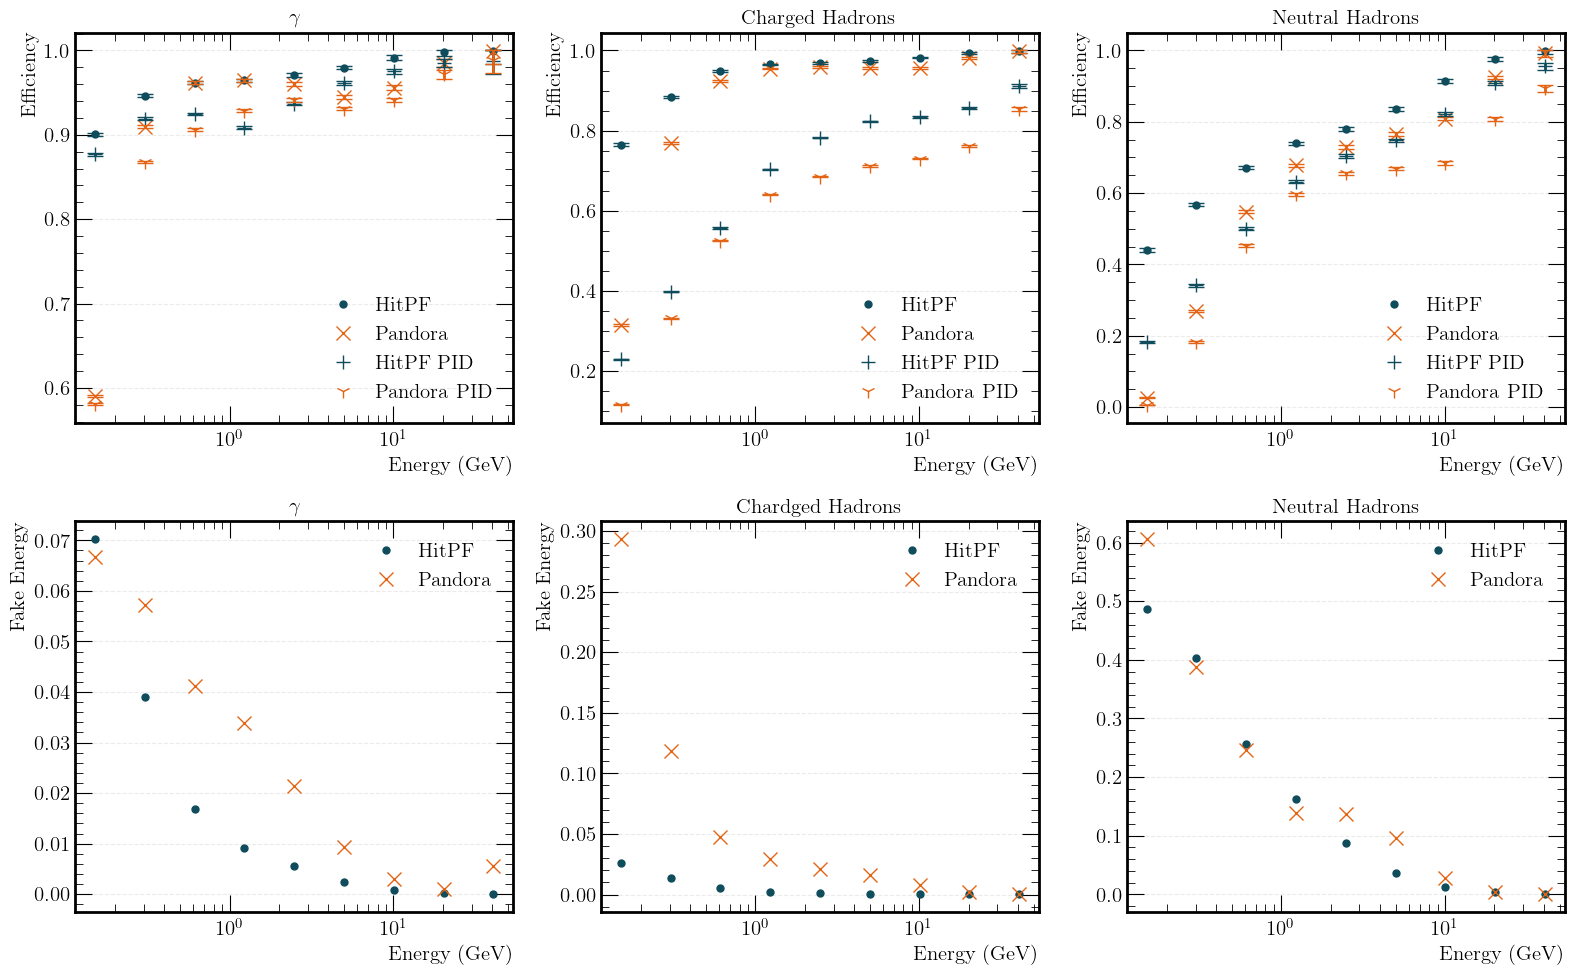

In [17]:
################################### Efficiency plot  FOR THE APPENDIX WITH PID AND FAKE ENERGY#####################################################################################################################################################################
######################################################################################################################################################################################################
fig_eff, ax_eff = plt.subplots(2, 3, figsize=(16, 10))
import matplotlib
plt.rc("text", usetex=True)
plt.rc("font", family="serif")

colors_list = ["#0F4C5C", "#E36414", "#E36414"]
STYLE_OURS = dict(color="#0F4C5C",  marker='.', linestyle='None', markersize=10) #lw=2.5, 
STYLE_PANDORA = dict(color="#E36414",  marker='x', linestyle='None', markersize=10)
STYLE_OURS_pid = dict(color="#0F4C5C",  marker='+', linestyle='None', markersize=10) #lw=2.5, 
STYLE_PANDORA_pid = dict(color="#E36414",  marker='1', linestyle='None', markersize=10)
ax_eff[0,0].plot(eff_dic["photons"]["energy_eff_" + str(0)],
            eff_dic["photons"]["eff" + "_" + str(0)], **STYLE_OURS,   label="HitPF")
ax_eff[0,0].plot(eff_dic["photons"]["energy_eff_p"],
            eff_dic["photons"]["eff_p"], **STYLE_PANDORA, label="Pandora")

ax_eff[0,0].plot(eff_dic["photons"]["energy_eff_" + str(0)],
            eff_dic["photons"]["eff_pid" + "_" + str(0)],label="HitPF PID", **STYLE_OURS_pid)
ax_eff[0,0].plot(eff_dic["photons"]["energy_eff_p"],
            eff_dic["photons"]["eff_p_pid"], label="Pandora PID", **STYLE_PANDORA_pid)
ax_eff[0,0].set_xlabel("Energy (GeV)",fontsize=size_font)
ax_eff[0,0].set_ylabel("Efficiency",fontsize=size_font)
ax_eff[0,0].set_title(r"$\gamma$",fontsize=size_font)
plot_error_bars(eff_dic["photons"],ax_eff[0,0], "")
plot_error_bars_pandora(eff_dic["photons"],ax_eff[0,0], "")
plot_error_bars(eff_dic["photons"],ax_eff[0,0], "_pid")
plot_error_bars_pandora(eff_dic["photons"],ax_eff[0,0], "_pid")


bins = np.exp(np.arange(np.log(0.1), np.log(80), 0.7))
bin_centers = 0.5 * (bins[:-1] + bins[1:])
bin_widths = np.diff(bins)
y = eff_dic["photons"]["eff_0"]
#################################
ax_eff[0,1].plot(eff_dic["pions"]["energy_eff_" + str(0)],
            eff_dic["pions"]["eff" + "_" + str(0)],  label="HitPF", **STYLE_OURS)
ax_eff[0,1].plot(eff_dic["pions"]["energy_eff_p"],
            eff_dic["pions"]["eff_p"], label="Pandora", **STYLE_PANDORA)
ax_eff[0,1].plot(eff_dic["pions"]["energy_eff_" + str(0)],
            eff_dic["pions"]["eff_pid" + "_" + str(0)],label="HitPF PID", **STYLE_OURS_pid)
ax_eff[0,1].plot(eff_dic["pions"]["energy_eff_p"],
            eff_dic["pions"]["eff_p_pid"], label="Pandora PID", **STYLE_PANDORA_pid)
plot_error_bars(eff_dic["pions"],ax_eff[0,1], "")
plot_error_bars(eff_dic["pions"],ax_eff[0,1], "_pid")
plot_error_bars_pandora(eff_dic["pions"],ax_eff[0,1], "_pid")
ax_eff[0,1].set_title("Charged Hadrons",fontsize=size_font)
ax_eff[0,1].set_xlabel("Energy (GeV)",fontsize=size_font)
ax_eff[0,1].set_ylabel("Efficiency",fontsize=size_font)
plot_error_bars_pandora(eff_dic["pions"],ax_eff[0,1], "")
#################################
ax_eff[0,2].plot(eff_dic["kaons"]["energy_eff_" + str(0)],
            eff_dic["kaons"]["eff" + "_" + str(0)], label="HitPF", **STYLE_OURS)
ax_eff[0,2].plot(eff_dic["kaons"]["energy_eff_p"],
            eff_dic["kaons"]["eff_p"], label="Pandora", **STYLE_PANDORA)
ax_eff[0,2].plot(eff_dic["kaons"]["energy_eff_" + str(0)],
            eff_dic["kaons"]["eff_pid" + "_" + str(0)],label="HitPF PID", **STYLE_OURS_pid)
ax_eff[0,2].plot(eff_dic["kaons"]["energy_eff_p"],
            eff_dic["kaons"]["eff_p_pid"], label="Pandora PID", **STYLE_PANDORA_pid)
plot_error_bars(eff_dic["kaons"],ax_eff[0,2], "")
plot_error_bars_pandora(eff_dic["kaons"],ax_eff[0,2], "")
plot_error_bars(eff_dic["kaons"],ax_eff[0,2], "_pid")
plot_error_bars_pandora(eff_dic["kaons"],ax_eff[0,2], "_pid")
ax_eff[0,2].set_xlabel("Energy (GeV)",fontsize=size_font)
ax_eff[0,2].set_title("Neutral Hadrons",fontsize=size_font)
ax_eff[0,2].set_ylabel("Efficiency",fontsize=size_font)

##Fake rate #################################
ax_eff[1,0].plot(eff_dic["photons"]["energy_fakes_" + str(0)],
            eff_dic["photons"]["fake_percent_energy_" + str(0)],  label="HitPF", **STYLE_OURS)
ax_eff[1,0].plot(eff_dic["photons"]["energy_fakes_p"],
        eff_dic["photons"]["fake_percent_energy_p"], label="Pandora", **STYLE_PANDORA)
ax_eff[1,0].set_xlabel("Energy (GeV)",fontsize=size_font)
ax_eff[1,0].set_ylabel("Fake Energy %",fontsize=size_font)
ax_eff[1,0].set_title(r"$\gamma$",fontsize=size_font)

#################################
ax_eff[1,1].plot(eff_dic["pions"]["energy_fakes_" + str(0)],
    eff_dic["pions"]["fake_percent_energy_" + str(0)],  label="HitPF", **STYLE_OURS)
ax_eff[1,1].plot(eff_dic["pions"]["energy_fakes_p"],
        eff_dic["pions"]["fake_percent_energy_p"], label="Pandora", **STYLE_PANDORA)
ax_eff[1,1].set_xlabel("Energy (GeV)",fontsize=size_font)
ax_eff[1,1].set_ylabel("Fake Energy %",fontsize=size_font)
ax_eff[1,1].set_title("Chardged Hadrons",fontsize=size_font)


ax_eff[1,2].plot(eff_dic["kaons"]["energy_fakes_" + str(0)],
    eff_dic["kaons"]["fake_percent_energy_" + str(0)],  label="HitPF", **STYLE_OURS)
ax_eff[1,2].plot(eff_dic["kaons"]["energy_fakes_p"],
        eff_dic["kaons"]["fake_percent_energy_p"], label="Pandora", **STYLE_PANDORA)
ax_eff[1,2].set_xlabel("Energy (GeV)",fontsize=size_font)
ax_eff[1,2].set_ylabel("Fake Energy %",fontsize=size_font)
ax_eff[1,2].set_title("Neutral Hadrons",fontsize=size_font)



legend_elements = [
    Line2D([0], [0], **STYLE_OURS, label="HitPF"),
    Line2D([0], [0], **STYLE_PANDORA, label="PandoraPFA"),
]


for ax in ax_eff.flatten():
    ax.grid(True, axis="y", alpha=0.25, linestyle="--")
    ax.set_axisbelow(True)
    ax.legend(fontsize = size_font)
    ax.set_xscale("log")
    ax.tick_params(axis='both', which='major', labelsize=size_font)
    ax.tick_params(axis='both', which='minor', labelsize=size_font)
plt.rcParams['font.size'] = size_font
plt.rcParams['font.family'] = "serif"
plt.rcParams['xtick.labelsize'] = size_font
plt.rcParams['ytick.labelsize'] = size_font
fig_eff.tight_layout()
fig_eff.savefig(os.path.join(PATH_store_summary_plots, "overview_Efficiency_FakeRate_PID_v1.pdf"))

/afs/cern.ch/work/m/mgarciam/private/mlpf/src/utils/inference/event_metrics.py:165: RuntimeWarning: invalid value encountered in divide
  pred_vect /= np.linalg.norm(pred_vect, axis=1).reshape(-1, 1)
/afs/cern.ch/work/m/mgarciam/private/mlpf/src/utils/inference/event_metrics.py:184: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  true_E_jet = scatter_sum(torch.tensor(true_e), batch_idx)
/afs/cern.ch/work/m/mgarciam/private/mlpf/src/utils/inference/event_metrics.py:185: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  true_E_jet_reco = scatter_sum(torch.tensor(reco_true_e), batch_idx)
/afs/cern.ch/work/m/mgarciam/private/mlpf/src/utils/inference/event_metrics.py:186: UserWarning: To copy const

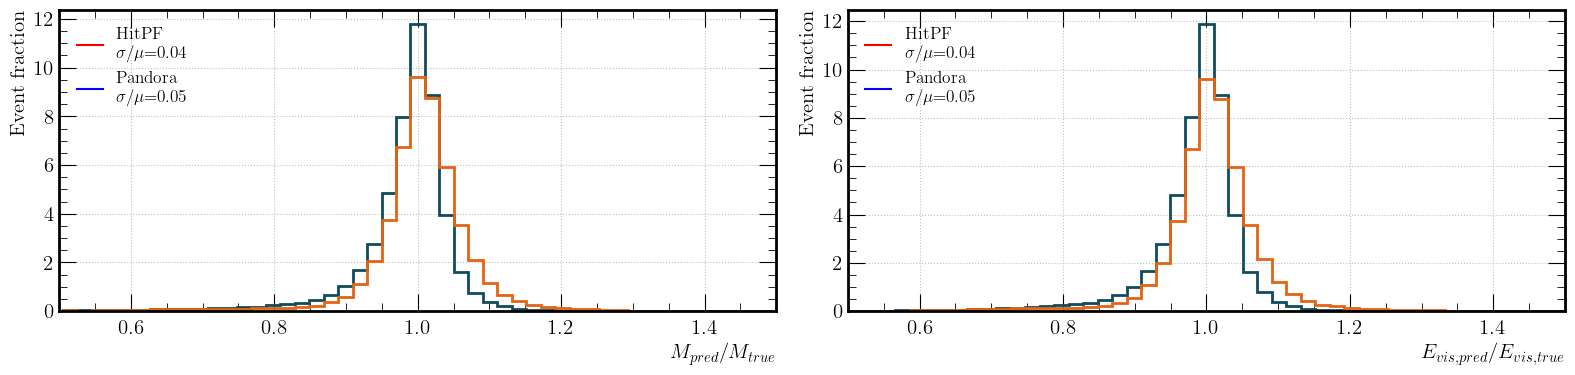

In [25]:
from src.utils.inference.event_metrics import get_response_for_event_energy
PATH_store = PATH_store_summary_plots
label_ML="HitPF"
label_ML_GTC="ML GTC",
color_ML_GTC="green"
filename="mass_resolution_comp.pdf"
perfect_pid = False
mass_zero = False
ML_pid = True
matched_all = {label_ML: sd_hgb, label_ML_GTC: sd_hgb_gt}
matched_pandora = sd_pandora
event_res_dic = {} 
for key in matched_all:
        matched_ = matched_all[key]
        event_res_dic[key] = get_response_for_event_energy(
                matched_pandora, matched_, perfect_pid=perfect_pid, mass_zero=mass_zero, ML_pid=ML_pid, pandora=True
            )




No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


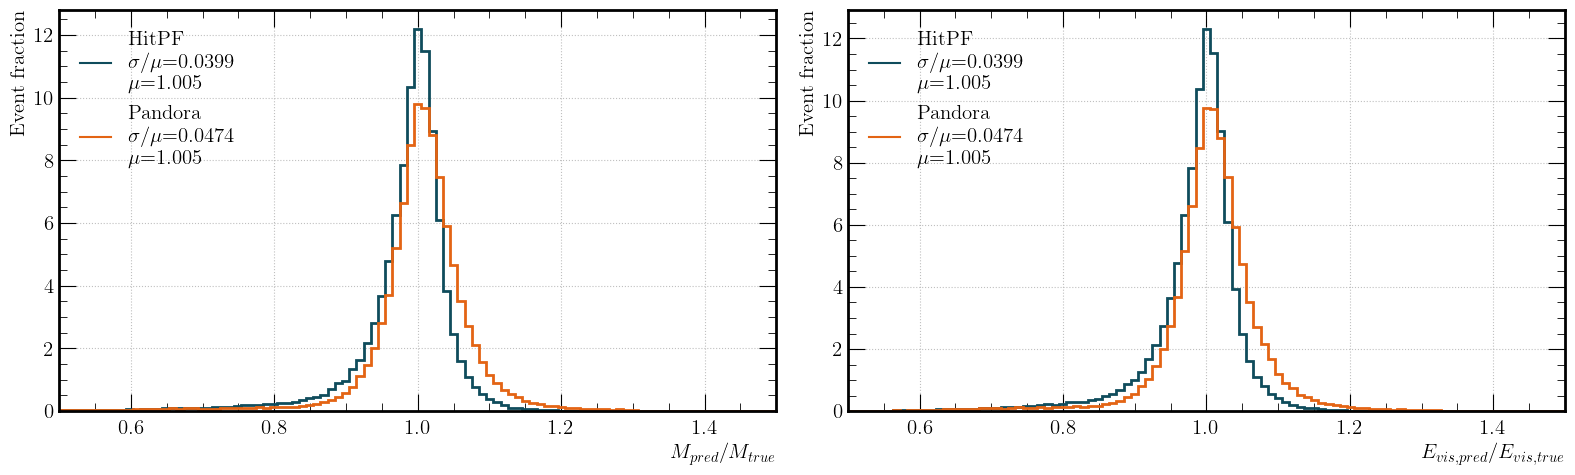

In [31]:
old_font_size = matplotlib.rcParams['font.size']
matplotlib.rcParams.update({'font.size': size_font})
fig, ax = plt.subplots(1, 2,figsize=(16, 5))
ax[0].set_xlabel(r"$M_{pred}/M_{true}$")
bins = np.linspace(0, 2, 200)
ax[0].hist(
    event_res_dic[label_ML]["mass_over_true_model"],
    bins=bins,
    histtype="step",
    color= "#0F4C5C",
    density=True, linewidth=2)

ax[0].hist(
    event_res_dic[label_ML]["mass_over_true_pandora"],
    bins=bins,
    histtype="step",
    color="#E36414",
    density=True,
    linewidth=2)

ax[0].grid()
ax[0].legend(loc='upper left')
mean_m_model = round((event_res_dic[label_ML]["mean_mass_model"]), 4)
var_m_model = round((event_res_dic[label_ML]["var_mass_model"]), 4)
mean_m_pandora = round((event_res_dic[label_ML]["mean_mass_pandora"]), 4)
var_m_pandora = round((event_res_dic[label_ML_GTC]["var_mass_pandora"]), 4)
mean_e_over_true_pandora, sigma_e_over_true_pandora = round(event_res_dic[label_ML]["mean_energy_over_true_pandora"], 4), round(
    event_res_dic[label_ML]["var_energy_over_true_pandora"], 4)
mean_e_over_true, sigma_e_over_true = round(event_res_dic[label_ML]["mean_energy_over_true"], 4), round(
    event_res_dic[label_ML]["var_energy_over_true"], 4)
mean_e_over_true_gtc, sigma_e_over_true_gtc = round(event_res_dic[label_ML_GTC]["mean_energy_over_true"], 4), round(
    event_res_dic[label_ML_GTC]["var_energy_over_true"], 4)
ax[1].hist(event_res_dic[label_ML]["energy_over_true"], bins=bins, histtype="step",
            # label=r"ML $\mu$={} $\sigma / \mu$={}".format(mean_e_over_true, sigma_e_over_true),
            color="#0F4C5C",
            density=True, linewidth=2)
   
ax[1].hist(event_res_dic[label_ML]["energy_over_true_pandora"], bins=bins, histtype="step",
                    # label=r"Pandora $\mu$={} $\sigma / \mu$={}".format(mean_e_over_true_pandora,
                    #                                                     sigma_e_over_true_pandora),
                    
                    color="#E36414",
                    density=True, linewidth=2)

ax[1].grid(1)
ax[1].set_xlabel(r"$E_{vis,pred} / E_{vis,true}$")
# ax[1].legend(loc='upper left')

from matplotlib.lines import Line2D
custom_line1 = Line2D([0], [0], color="#0F4C5C",label="HitPF "+"\n"+"$\sigma/\mu$={}".format(var_m_model)
    +"\n"+ " $\mu$={}".format(mean_m_model))
# custom_line_gt = Line2D([0], [0], color="green",label="ML GT "+"\n"+"$\sigma/\mu$={}".format(round((event_res_dic["ML GTC"]["var_mass_model"]), 2),
#     ))
custom_line_pandora = Line2D([0], [0], color="#E36414",label="Pandora "+"\n"+"$\sigma/\mu$={}".format(var_m_pandora
    )+"\n"+ " $\mu$={}".format(mean_m_pandora))

custom_line2 = Line2D([0], [0], color="#0F4C5C",label="HitPF "+"\n"+"$\sigma/\mu$={}".format(sigma_e_over_true)
    +"\n"+ " $\mu$={}".format(mean_e_over_true))
# custom_line_gt = Line2D([0], [0], color="green",label="ML GT "+"\n"+"$\sigma/\mu$={}".format(round((event_res_dic["ML GTC"]["var_mass_model"]), 2),
#     ))
custom_line_pandora2 = Line2D([0], [0], color="#E36414",label="Pandora "+"\n"+"$\sigma/\mu$={}".format(sigma_e_over_true_pandora)+"\n"+ " $\mu$={}".format(mean_e_over_true_pandora))
ax[1].legend(handles=[custom_line1, custom_line_pandora],loc='upper left')
ax[0].legend(handles=[custom_line2, custom_line_pandora2],loc='upper left')
# ax.legend(loc='upper left')
ax[0].set_xlim([0.5, 1.5])
ax[1].set_xlim([0.5, 1.5])
ax[0].set_ylabel("Event fraction")
ax[1].set_ylabel("Event fraction")
plt.rc("text", usetex=True)
plt.rc("font", family="serif")
plt.rcParams['text.usetex'] = True
plt.rcParams['font.size'] = size_font
plt.rcParams['axes.labelsize'] = size_font
plt.rcParams['xtick.labelsize'] = size_font
plt.rcParams['ytick.labelsize'] = size_font
plt.rcParams['legend.fontsize'] = size_font
fig.tight_layout()
fig.savefig(os.path.join(PATH_store, filename), bbox_inches="tight")



In [5]:
from src.utils.inference.per_particle_metrics import get_mask_id, particle_masses, particle_masses_4_class, safeint
from src.utils.inference.inference_metrics import get_sigma_gaussian

def calculate_response(matched, pandora, log_scale=False, tracks=False, perfect_pid=False, mass_zero=False, ML_pid=False, pid=None):
    if log_scale:
        bins = np.exp(np.arange(np.log(0.1), np.log(80), 0.3))
    else:
        #bins = np.linspace(0, 51, 5)
        bins = [0, 5, 15,  51]
    mean = []
    variance_om = []
    mean_baseline = []
    variance_om_baseline = []
    mean_true_rec = []
    variance_om_true_rec = []
    mean_errors = []
    variance_om_errors = []
    energy_resolutions = []
    energy_resolutions_reco = []
    distributions = []  # Distributions of E/E_{true} for plotting later
    distributions_reco = []
    mean_pxyz = []
    variance_pxyz = []
    masses = []
    is_track_in_cluster = []
    pxyz_true, pxyz_pred = [], []
    sigma_phi, sigma_theta = [], [] # for the angular resolution vs. energy
    distr_phi, distr_theta = [], []
    #binning = 1e-2 * 0.2
    bins_per_binned_E = np.linspace(0, 2, 1000)

    for i in range(len(bins) - 1):
        bin_i = bins[i]
        bin_i1 = bins[i + 1]
        mask_above = matched["true_showers_E"] <= bin_i1
        mask_below = matched["true_showers_E"] > bin_i
        mask_check = ~pd.isna(matched["pred_showers_E"])
        mask = mask_below * mask_above * mask_check
        true_e = matched.true_showers_E[mask]
        true_rec = matched.reco_showers_E[mask]
        print("sum mask", bin_i, bin_i1, np.sum(mask))
        if pandora:
            pred_e = matched.pandora_calibrated_pfo[mask]
            pred_pxyz = np.array(matched.pandora_calibrated_pos[mask].tolist())
        else:
            pred_e = matched.calibrated_E[mask]
            pred_pxyz = np.array(matched.pred_pos_matched[mask].tolist())
        pred_e_nocor = matched.pred_showers_E[mask]
        trk_in_clust = matched.is_track_in_cluster[mask]
        if perfect_pid or mass_zero or ML_pid:
            if len(pred_pxyz):
                pred_pxyz /= np.linalg.norm(pred_pxyz, axis=1).reshape(-1, 1)
            if perfect_pid:
                m = np.array([particle_masses[abs(int(i))] for i in matched.pid[mask]])
            elif ML_pid:
                if pandora:
                    print("Using Pandora PID")
                    m = np.array([particle_masses[abs(int(i))] for i in matched.pandora_pid[mask]])
                else:
                    m = np.array([particle_masses_4_class.get(safeint(i), 0.0) for i in matched.pred_pid_matched[mask]])
            if mass_zero:
                m = np.array([0 for _ in range(len(matched.pid[mask]))])
            p_squared = (pred_e**2 - m**2).values
            pred_pxyz = np.sqrt(p_squared).reshape(-1, 1) * pred_pxyz
        true_pxyz = np.array(matched.true_pos[mask].tolist())

        if np.sum(mask) > 0:  # if the bin is not empty
            e_over_true = pred_e / true_e
            e_over_reco = true_rec / true_e
            e_over_reco_ML = pred_e_nocor / true_rec
            pxyz_over_true = pred_pxyz / true_pxyz
            dist, _, phi_dist, eta_dist = calc_unit_circle_dist(matched[mask], pandora=pandora)
            #if eta_dist.abs().max() < 0.01:
            #    bins_angle = np.linspace(-0.01, +0.01, 1000)
            p_size_over_true = np.linalg.norm(pred_pxyz, axis=1) / np.linalg.norm(true_pxyz, axis=1)
            #mu, var, _, _ = get_sigma_gaussian(phi_dist, bins_angle)
            bins_angle = np.linspace(-0.05, +0.05, 1000)

            if pid in [211, -211, 2212, -2212, 11, -11] and i in [1, 2]:
                bins_angle = np.linspace(-0.01, 0.01, 1000)
            mu, var_phi , _ , _= get_sigma_gaussian(phi_dist, bins_angle, return_gaussian=False, return_divided=False)
            #mu, var, _, _ = get_sigma_gaussian(eta_dist, bins_angle)
            mu, var_theta , _, _= get_sigma_gaussian(eta_dist, bins_angle, return_gaussian=False, return_divided=False)
            sigma_phi.append(var_phi)
            sigma_theta.append(var_theta)
            distr_theta.append(eta_dist)
            distr_phi.append(phi_dist)
            distributions.append(e_over_true)
            distributions_reco.append(e_over_reco_ML)
            bins_per_binned_E = np.linspace(0, 2, 2000)
            (
                mean_predtotrue,
                var_predtotrue,
                err_mean_predtotrue,
                err_var_predtotrue,
            ) = get_sigma_gaussian(e_over_true, bins_per_binned_E)
            pred_ps = np.linalg.norm(pred_pxyz, axis=1)
            masses.append((torch.tensor(pred_e.values) ** 2 - torch.tensor(pred_ps) ** 2))
            (
                mean_reco_true,
                var_reco_true,
                err_mean_reco_true,
                err_var_reco_true,
            ) = get_sigma_gaussian(e_over_reco, bins_per_binned_E)
            (
                mean_reco_ML,
                var_reco_ML,
                err_mean_reco_ML,
                err_mean_var_reco_ML,
            ) = get_sigma_gaussian(e_over_reco_ML, bins_per_binned_E)
            if not pandora:
                print("Not Pandora")
            mean_pxyz_, var_pxyz_ = [], []
            pxyz_true.append(true_pxyz)
            pxyz_pred.append(pred_pxyz)
            for i in [0, 1, 2]: # x, y, z
                (
                    mean_px,
                    var_px,
                    _,
                    _,
                ) = get_sigma_gaussian(pxyz_over_true[:, i], bins_per_binned_E)
                mean_pxyz_.append(mean_px)
                var_pxyz_.append(var_px)
            (
                mean_px,
                var_px,
                _,
                _,
            ) = get_sigma_gaussian(p_size_over_true, bins_per_binned_E)
            mean_pxyz_.append(mean_px)
            var_pxyz_.append(var_px)
            #mean_pxyz_ = np.array(mean_pxyz_)
            #var_pxyz_ = np.array(var_pxyz_)
            # raise err if mean_reco_ML is nan
            #if np.isnan(mean_reco_ML):
            #    raise ValueError("mean_reco_ML is nan")
            mean_true_rec.append(mean_reco_ML)
            variance_om_true_rec.append(np.abs(var_reco_ML))
            mean_baseline.append(mean_reco_true)
            variance_om_baseline.append(np.abs(var_reco_true))
            mean.append(mean_predtotrue)
            variance_om.append(np.abs(var_predtotrue))
            energy_resolutions.append((bin_i1 + bin_i) / 2)
            energy_resolutions_reco.append((bin_i1 + bin_i) / 2)
            mean_errors.append(err_mean_predtotrue)
            variance_om_errors.append(err_var_predtotrue)
            mean_pxyz.append(mean_pxyz_)
            variance_pxyz.append(var_pxyz_)
            is_track_in_cluster.append(trk_in_clust)

    return (
        mean,
        variance_om,
        mean_true_rec,
        variance_om_true_rec,
        energy_resolutions,
        energy_resolutions_reco,
        mean_baseline,
        variance_om_baseline,
        distributions,
        mean_errors,
        variance_om_errors,
        np.array(mean_pxyz),
        np.array(variance_pxyz),
        [masses, is_track_in_cluster],
        pxyz_true,
        pxyz_pred,
        sigma_phi,
        sigma_theta,
        distr_phi,
        distr_theta,
        distributions_reco
    )
def get_response_for_id_i(id, matched_pandora, matched_, tracks=False, perfect_pid=False, mass_zero=False, ML_pid=False, pandora=False):
    if pandora:
        pids_pandora = np.abs(matched_pandora["pid"].values)
        mask_id = get_mask_id(id, pids_pandora)
        df_id_pandora = matched_pandora[mask_id]
    pids = np.abs(matched_["pid"].values)
    mask_id = get_mask_id(id, pids)
    df_id = matched_[mask_id]
    if pandora:
        (
            mean_p,
            variance_om_p,
            mean_true_rec_p,
            variance_om_true_rec_p,
            energy_resolutions_p,
            energy_resolutions_reco_p,
            mean_baseline,
            variance_om_baseline,
            e_over_e_distr_pandora,
            mean_errors_p,
            variance_errors_p,
            mean_pxyz_pandora, variance_om_pxyz_pandora, masses_pandora, pxyz_true_p, pxyz_pred_p, sigma_phi_pandora, sigma_theta_pandora, distr_phi_pandora, distr_theta_pandora, distr_E_reco_pandora
        ) = calculate_response(df_id_pandora, True, True, tracks=tracks, perfect_pid=perfect_pid, mass_zero=mass_zero, ML_pid=ML_pid, pid=id[0])
        # Pandora: TODO: do some sort of PID for Pandora
    (
        mean,
        variance_om,
        mean_true_rec,
        variance_om_true_rec,
        energy_resolutions,
        energy_resolutions_reco,
        mean_baseline,
        variance_om_baseline,
        e_over_e_distr_model,
        mean_errors,
        variance_errors,
        mean_pxyz, variance_om_pxyz, masses, pxyz_true, pxyz_pred, sigma_phi, sigma_theta, distr_phi, distr_theta, distr_E_reco
    ) = calculate_response(df_id, False, True, tracks=tracks, perfect_pid=perfect_pid, mass_zero=mass_zero, ML_pid=ML_pid, pid=id[0])
    # print("COR:__________________________________")
    # print(variance_om_p)
    # print(variance_om)
    # print("RECO:__________________________________")
    # print(variance_om_true_rec_p)
    # print(variance_om_true_rec)
    dic = {}
    if pandora:
        dic["mean_p"] = mean_p
        dic["variance_om_p"] = variance_om_p
        dic["variance_errors_p"] = np.array(variance_errors_p)
        dic["mean_errors_p"] = np.array(mean_errors_p)
        dic["energy_resolutions_p"] = np.array(energy_resolutions_p)
        dic["mean_p_reco"] = np.array(mean_true_rec_p)
        dic["variance_om_p_reco"] = np.array(variance_om_true_rec_p)
        dic["energy_resolutions_p_reco"] = np.array(energy_resolutions_reco_p)
        dic["distributions_pandora"] = e_over_e_distr_pandora
        dic["distributions_pandora_reco"] = distr_E_reco_pandora
        dic["mean_pxyz_pandora"] = mean_pxyz_pandora
        dic["variance_om_pxyz_pandora"] = variance_om_pxyz_pandora
        dic["distr_phi_pandora"] = distr_phi_pandora
        dic["distr_theta_pandora"] = distr_theta_pandora
        dic["sigma_phi_pandora"] = sigma_phi_pandora
        dic["sigma_theta_pandora"] = sigma_theta_pandora
        dic["pxyz_true_p"] = pxyz_true_p
        dic["pxyz_pred_p"] = pxyz_pred_p
        dic["mass_histogram_pandora"] = masses_pandora

    dic["variance_om"] = variance_om
    dic["mean"] = mean
    dic["mean_errors"] = np.array(mean_errors)
    dic["variance_errors"] = np.array(variance_errors)
    dic["energy_resolutions"] = np.array(energy_resolutions)
    dic["mean_reco"] = mean_true_rec
    dic["variance_om_reco"] = np.array(variance_om_true_rec)
    dic["energy_resolutions_reco"] = np.array(energy_resolutions_reco)
    dic["mean_baseline"] = mean_baseline
    dic["variance_om_baseline"] = np.array(variance_om_baseline)
    dic["distributions_model"] = e_over_e_distr_model
    dic["distributions_model_reco"] = distr_E_reco
    dic["mean_pxyz"] = mean_pxyz
    dic["variance_om_pxyz"] = variance_om_pxyz
    dic["mass_histogram"] = masses
    dic["pxyz_true"] = pxyz_true
    dic["pxyz_pred"] = pxyz_pred
    dic["sigma_phi"] = sigma_phi
    dic["sigma_theta"] = sigma_theta
    dic["distr_phi"] = distr_phi
    dic["distr_theta"] = distr_theta
    
    return dic

In [6]:
tracks = True
# from src.utils.inference.per_particle_metrics import get_response_for_id_i
perfect_pid = False
mass_zero = False
pandora = True
ML_pid = True
matched_pandora = sd_pandora1
matched_ = sd_hgb1
print("PID:22___________________________________________")
photons_dic = get_response_for_id_i(
    [22], matched_pandora[matched_pandora.pandora_pid==22], matched_[matched_.pred_pid_matched==3], tracks=tracks, perfect_pid=perfect_pid, mass_zero=mass_zero,pandora=pandora, 
    ML_pid=ML_pid
)

print("PID:211___________________________________________")
hadrons_dic2 = get_response_for_id_i(
    [211], matched_pandora[np.abs(matched_pandora.pandora_pid)==211], matched_[matched_.pred_pid_matched==1], tracks=tracks, perfect_pid=perfect_pid, mass_zero=mass_zero, ML_pid=ML_pid,pandora=pandora
)
print("PID:neutron___________________________________________")
neutrons = get_response_for_id_i(
    [2112], matched_pandora[np.abs(matched_pandora.pandora_pid)==2112], matched_[matched_.pred_pid_matched==2], tracks=tracks, perfect_pid=perfect_pid, mass_zero=mass_zero, ML_pid=ML_pid,pandora=pandora
)


PID:22___________________________________________
sum mask 0.10000000000000002 0.13498588075760032 21917
Using Pandora PID
sum mask 0.13498588075760032 0.1822118800390509 40495
Using Pandora PID
sum mask 0.1822118800390509 0.2459603111156949 56603
Using Pandora PID
sum mask 0.2459603111156949 0.33201169227365457 65223
Using Pandora PID
sum mask 0.33201169227365457 0.4481689070338062 68284
Using Pandora PID
sum mask 0.4481689070338062 0.604964746441294 65592
Using Pandora PID
sum mask 0.604964746441294 0.8166169912567641 62186
Using Pandora PID
sum mask 0.8166169912567641 1.1023176380641588 58661
Using Pandora PID
sum mask 1.1023176380641588 1.4879731724872813 55817
Using Pandora PID
sum mask 1.4879731724872813 2.0085536923187637 52347
Using Pandora PID
sum mask 2.0085536923187637 2.711263892065784 48357
Using Pandora PID
sum mask 2.711263892065784 3.6598234443677917 43675
Using Pandora PID
sum mask 3.6598234443677917 4.940244910553007 38435
Using Pandora PID
sum mask 4.940244910553007 

/afs/cern.ch/work/m/mgarciam/private/mlpf/src/utils/inference/inference_metrics.py:167: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  MPV, std68 = torch.mean(torch.tensor(data_for_hist)).item(), torch.std(torch.tensor(data_for_hist)).item()


sum mask 0.2459603111156949 0.33201169227365457 425
Using Pandora PID
sum mask 0.33201169227365457 0.4481689070338062 5849
Using Pandora PID
sum mask 0.4481689070338062 0.604964746441294 17884
Using Pandora PID
sum mask 0.604964746441294 0.8166169912567641 28365
Using Pandora PID
sum mask 0.8166169912567641 1.1023176380641588 38550
Using Pandora PID
sum mask 1.1023176380641588 1.4879731724872813 39967
Using Pandora PID
sum mask 1.4879731724872813 2.0085536923187637 40590
Using Pandora PID
sum mask 2.0085536923187637 2.711263892065784 41107
Using Pandora PID
sum mask 2.711263892065784 3.6598234443677917 40151
Using Pandora PID
sum mask 3.6598234443677917 4.940244910553007 39156
Using Pandora PID
sum mask 4.940244910553007 6.668633104092499 37519
Using Pandora PID
sum mask 6.668633104092499 9.00171313005216 34456
Using Pandora PID
sum mask 9.00171313005216 12.151041751873457 30503
Using Pandora PID
sum mask 12.151041751873457 16.402190729990128 24668
Using Pandora PID
sum mask 16.4021907

/afs/cern.ch/work/m/mgarciam/private/miniconda/miniconda3/envs/graphgps0/lib/python3.10/site-packages/numpy/lib/histograms.py:885: RuntimeWarning: divide by zero encountered in divide
  return n/db/n.sum(), bin_edges
/afs/cern.ch/work/m/mgarciam/private/miniconda/miniconda3/envs/graphgps0/lib/python3.10/site-packages/numpy/lib/histograms.py:885: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


Not Pandora
sum mask 0.2459603111156949 0.33201169227365457 158


/tmp/mgarciam/ipykernel_4162296/2390918341.py:64: RuntimeWarning: invalid value encountered in sqrt
  pred_pxyz = np.sqrt(p_squared).reshape(-1, 1) * pred_pxyz


Not Pandora
sum mask 0.33201169227365457 0.4481689070338062 5336
Not Pandora
sum mask 0.4481689070338062 0.604964746441294 15891
Not Pandora
sum mask 0.604964746441294 0.8166169912567641 30258
Not Pandora
sum mask 0.8166169912567641 1.1023176380641588 44611
Not Pandora
sum mask 1.1023176380641588 1.4879731724872813 46679
Not Pandora
sum mask 1.4879731724872813 2.0085536923187637 44899
Not Pandora
sum mask 2.0085536923187637 2.711263892065784 46659
Not Pandora
sum mask 2.711263892065784 3.6598234443677917 46431
Not Pandora
sum mask 3.6598234443677917 4.940244910553007 45302
Not Pandora
sum mask 4.940244910553007 6.668633104092499 43116
Not Pandora
sum mask 6.668633104092499 9.00171313005216 39370
Not Pandora
sum mask 9.00171313005216 12.151041751873457 34618
Not Pandora
sum mask 12.151041751873457 16.402190729990128 28079
Not Pandora
sum mask 16.402190729990128 22.14064162041864 20337
Not Pandora
sum mask 22.14064162041864 29.88674009670593 12126
Not Pandora
sum mask 29.88674009670593 4

In [21]:
### E resolution with PID
photon_edir = photons_dic
ch_edir = hadrons_dic2
nh_edir = neutrons
plt.rc("text", usetex=True)
plt.rc("font", family="serif")
colors_list = ["#0F4C5C", "#E36414", "#E36414"]
STYLE_OURS = dict(color="#0F4C5C",  marker='.', linestyle='None', markersize=10) #lw=2.5, 
STYLE_PANDORA = dict(color="#E36414",  marker='x', linestyle='None', markersize=10)
fig, ax_eff = plt.subplots(1, 3,figsize=(16, 5))
bins = [0, 5, 15, 50]
bin_labels = [f"[{bins[i]},{bins[i + 1]}]" for i in range(len(bins) - 1)]
ax_eff[0].plot(photon_edir["energy_resolutions_p"], photon_edir["variance_om_p"] / photon_edir["energy_resolutions_p"], **STYLE_PANDORA,label="Pandora")
ax_eff[0].plot(photon_edir["energy_resolutions"], photon_edir["variance_om_baseline"] / photon_edir["energy_resolutions"], ".--", c="k", label="Baseline")

ax_eff[0].plot(photon_edir["energy_resolutions"],photon_edir["variance_om"] / photon_edir["energy_resolutions"], label="HitPF", **STYLE_OURS)
ax_eff[0].set_xlabel("Energy [GeV]")
ax_eff[0].set_title(r"$\gamma$")
ax_eff[0].set_ylabel("$\sigma_E / E$")
ax_eff[0].set_xticks([2.5, 10.0, 33.0])
ax_eff[0].set_xticklabels(bin_labels, fontsize=10)  # Set the corresponding bin range labels
ax_eff[0].tick_params(axis='x', which='both', direction='inout')

ax_eff[1].plot(ch_edir["energy_resolutions_p"], ch_edir["variance_om_p"] / ch_edir["energy_resolutions_p"], **STYLE_PANDORA,label="Pandora")
# ax_eff[1].plot(ch_edir["energy_resolutions"], ch_edir["variance_om_baseline"] / ch_edir["energy_resolutions"], ".--", c="k", label="Baseline")

ax_eff[1].plot(ch_edir["energy_resolutions"],ch_edir["variance_om"] / ch_edir["energy_resolutions"], label="HitPF", **STYLE_OURS)
ax_eff[1].set_xlabel("Energy [GeV]")
ax_eff[1].set_title("Charged Hadrons")
ax_eff[1].set_ylabel("$\sigma_E / E$")
ax_eff[1].set_xticks([2.5, 10.0, 33.0])
ax_eff[1].set_xticklabels(bin_labels, fontsize=10)  # Set the corresponding bin range labels
ax_eff[1].tick_params(axis='x', which='both', direction='inout')


ax_eff[2].plot(nh_edir["energy_resolutions_p"], nh_edir["variance_om_p"] / nh_edir["energy_resolutions_p"], **STYLE_PANDORA,label="Pandora")
ax_eff[2].plot(nh_edir["energy_resolutions"], nh_edir["variance_om_baseline"] / nh_edir["energy_resolutions"], ".--", c="k", label="Baseline")

ax_eff[2].plot(nh_edir["energy_resolutions"],nh_edir["variance_om"] / nh_edir["energy_resolutions"], label="HitPF", **STYLE_OURS)
ax_eff[2].set_xlabel("Energy [GeV]")
ax_eff[2].set_title("Neutral Hadrons")
ax_eff[2].set_ylabel("$\sigma_E / E$")
ax_eff[2].set_xticks([2.5, 10.0, 33.0])
ax_eff[2].set_xticklabels(bin_labels, fontsize=10)  # Set the corresponding bin range labels
ax_eff[2].tick_params(axis='x', which='both', direction='inout')
size_font = 12
for ax in ax_eff.flatten():
    ax.grid(True, axis="y", alpha=0.25, linestyle="--")
    ax.set_axisbelow(True)
    ax.legend(fontsize = size_font)
    ax.set_xscale("log")
    ax.tick_params(axis='both', which='major', labelsize=size_font)
    ax.tick_params(axis='both', which='minor', labelsize=size_font)
plt.rcParams['text.usetex'] = True
plt.rcParams['font.size'] = size_font
plt.rcParams['axes.labelsize'] = size_font
plt.rcParams['xtick.labelsize'] = size_font
plt.rcParams['ytick.labelsize'] = size_font
plt.rcParams['legend.fontsize'] = size_font
fig.tight_layout()
fig.savefig(os.path.join(PATH_store, "e_resolution.pdf"), bbox_inches="tight")
